# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muneebulhaq02/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muneebulhaq02/flyrank-ml-internship"
REPO_DIR = "FlyRank-Internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())


Working dir: /content/FlyRank-Internship


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked Actions and Reason Codes

The purpose of this playbook is to prioritize pages for manual review based on measurable search performance signals.

Each page receives a recommendation together with one or more reason codes so that editors understand why the page appears in the review queue.

The current action categories are:

- Refresh Content – Older content with strong visibility but declining performance.

- Improve CTR – Pages receiving many impressions but relatively few clicks.

- Improve Search Position – Pages ranking below stronger competitors.

- Monitor – Pages performing normally that should continue to be observed.


These recommendations are intended as decision-support, not automatic publishing actions.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

playbook = df.copy()

playbook["Reason Code"] = ""
playbook["Recommended Action"] = "Monitor"

playbook.loc[
    playbook["content_age_days"] > 365,
    "Reason Code"
] += "Old Content; "

playbook.loc[
    playbook["ctr"] < playbook["ctr"].median(),
    "Reason Code"
] += "Low CTR; "

playbook.loc[
    playbook["avg_position"] > playbook["avg_position"].median(),
    "Reason Code"
] += "Poor Position; "

playbook.loc[
    playbook["impressions_90d"] >
    playbook["impressions_90d"].median(),
    "Reason Code"
] += "High Visibility; "

playbook.loc[
    playbook["Reason Code"].str.contains("Old Content"),
    "Recommended Action"
] = "Refresh Content"

playbook.loc[
    playbook["Reason Code"].str.contains("Low CTR"),
    "Recommended Action"
] = "Improve CTR"

playbook.loc[
    playbook["Reason Code"].str.contains("Poor Position"),
    "Recommended Action"
] = "Improve Search Position"

playbook[
    [
        "Recommended Action",
        "Reason Code",
        "impressions_90d",
        "ctr",
        "avg_position"
    ]
].head(10)

,Recommended Action,Reason Code,impressions_90d,ctr,avg_position
0,Monitor,High Visibility;,3803,0.76,10.6
1,Improve Search Position,Old Content; Low CTR; Poor Position; High Visi...,15320,0.05,20.3
2,Improve Search Position,Poor Position; High Visibility;,12581,0.09,36.5
3,Refresh Content,Old Content; High Visibility;,11751,0.49,6.2
4,Improve Search Position,Poor Position; High Visibility;,19140,0.13,44.0
5,Improve CTR,Low CTR; High Visibility;,3970,0.03,8.5
6,Improve CTR,Low CTR;,20,0.00,7.0
7,Improve Search Position,Old Content; Low CTR; Poor Position; High Visi...,1724,0.06,21.2
8,Improve Search Position,Poor Position; High Visibility;,32574,0.09,46.0
9,Monitor,High Visibility;,1240,0.16,4.9


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use and Limits

This playbook is designed to help SEO analysts and content editors prioritize which pages should be reviewed first.

The recommendations are based only on observed patterns in the available dataset.

The output should be treated as decision-support rather than an automated decision system.

Performance may differ for new websites, seasonal content, or pages affected by external factors that are not represented in the dataset.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
summary = pd.DataFrame({
    "Purpose":[
        "Content review prioritization"
    ],
    "Primary Users":[
        "SEO Analysts and Content Editors"
    ],
    "Output":[
        "Ranked review queue"
    ],
    "Automation":[
        "Decision support only"
    ]
})

summary

,Purpose,Primary Users,Output,Automation
0,Content review prioritization,SEO Analysts and Content Editors,Ranked review queue,Decision support only


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review

Every recommendation should be reviewed by a content editor before changes are made.

Editors should verify:

- Content quality

- Current relevance

- Search intent

- Technical SEO

- Business importance

## No-Go List

The following actions should never be automated solely from this model:

- deleting content

- merging pages

- changing page titles automatically

- changing URLs

- publishing rewritten content

- removing internal links

Human judgment remains essential before implementing any recommendation.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
review_rules = [
    "Review page quality",
    "Check search intent",
    "Verify CTR",
    "Review keyword relevance",
    "Confirm business value"
]

no_go = [
    "Delete page automatically",
    "Rewrite content automatically",
    "Change URLs automatically",
    "Merge pages automatically",
    "Publish AI content without review"
]

print("Human Review Checklist")
for r in review_rules:
    print("-", r)

print()

print("No-Go List")
for n in no_go:
    print("-", n)

Human Review Checklist
- Review page quality
- Check search intent
- Verify CTR
- Review keyword relevance
- Confirm business value

No-Go List
- Delete page automatically
- Rewrite content automatically
- Change URLs automatically
- Merge pages automatically
- Publish AI content without review


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

# Monitoring and Retraining

The recommendation system should be monitored regularly.

Retraining should be considered when:

- new monthly search data becomes available
- CTR distributions change substantially
- search rankings shift across many pages
- the feature distributions differ noticeably from the training data
- model performance declines on newly collected evaluation data

Regular monitoring helps ensure that recommendations remain relevant over time.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring = pd.DataFrame({
    "Trigger":[
        "New monthly data",
        "CTR distribution changes",
        "Ranking shifts",
        "Feature drift",
        "Model performance decline"
    ],
    "Action":[
        "Retrain model",
        "Review thresholds",
        "Recompute features",
        "Revalidate model",
        "Retrain and compare"
    ]
})

monitoring

,Trigger,Action
0,New monthly data,Retrain model
1,CTR distribution changes,Review thresholds
2,Ranking shifts,Recompute features
3,Feature drift,Revalidate model
4,Model performance decline,Retrain and compare


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

# Exporting Artifacts

The ranked recommendations generated in this notebook will be reused in the final research paper.

The notebook exports the recommendation queue to the required output directory.

If charts are generated later, they should be saved under work/figures/ for reuse in the deployed paper.

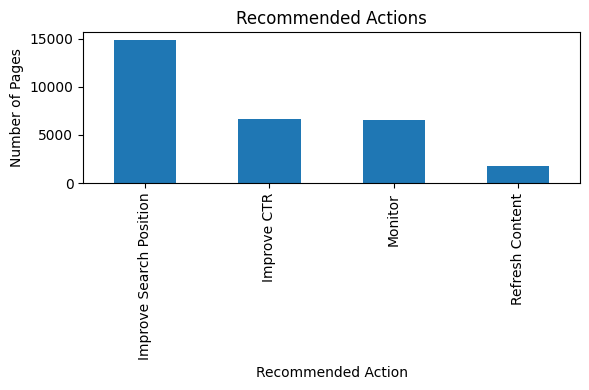

Files exported successfully.
work/outputs/content_action_playbook.csv
work/figures/recommended_actions.png


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export ranked queue
playbook.to_csv(
    "work/outputs/content_action_playbook.csv",
    index=False
)

# Create a simple figure for the paper
plt.figure(figsize=(6,4))

playbook["Recommended Action"].value_counts().plot(kind="bar")

plt.title("Recommended Actions")
plt.ylabel("Number of Pages")

plt.tight_layout()

plt.savefig(
    "work/figures/recommended_actions.png"
)

plt.show()

print("Files exported successfully.")
print("work/outputs/content_action_playbook.csv")
print("work/figures/recommended_actions.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.